In [12]:
import pandas as pd 
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.utils import add_self_loops

In [13]:
# edge_list = pd.read_csv('DataDiatomGNN_GTstudentprojectGT/EdgeList_GTstudentproject_Watershed=Loire-Bretagne_477MostFrequentTaxa_RelAb_spearman_rhothr=0.0321.csv', sep=';')
edge_list = pd.read_csv('DataDiatomGNN_GTstudentprojectGT/EdgeList_GTstudentproject_AllFrance_780MostFrequentTaxa_RelAb_spearman_rhothr=0.0131.csv', sep=';')
edge_list['Cooc'] = edge_list['Cooc'].str.replace(',','.')
edge_list['Cooc'] = edge_list['Cooc'].astype(float)

100%|██████████| 10307/10307 [01:09<00:00, 147.58it/s]


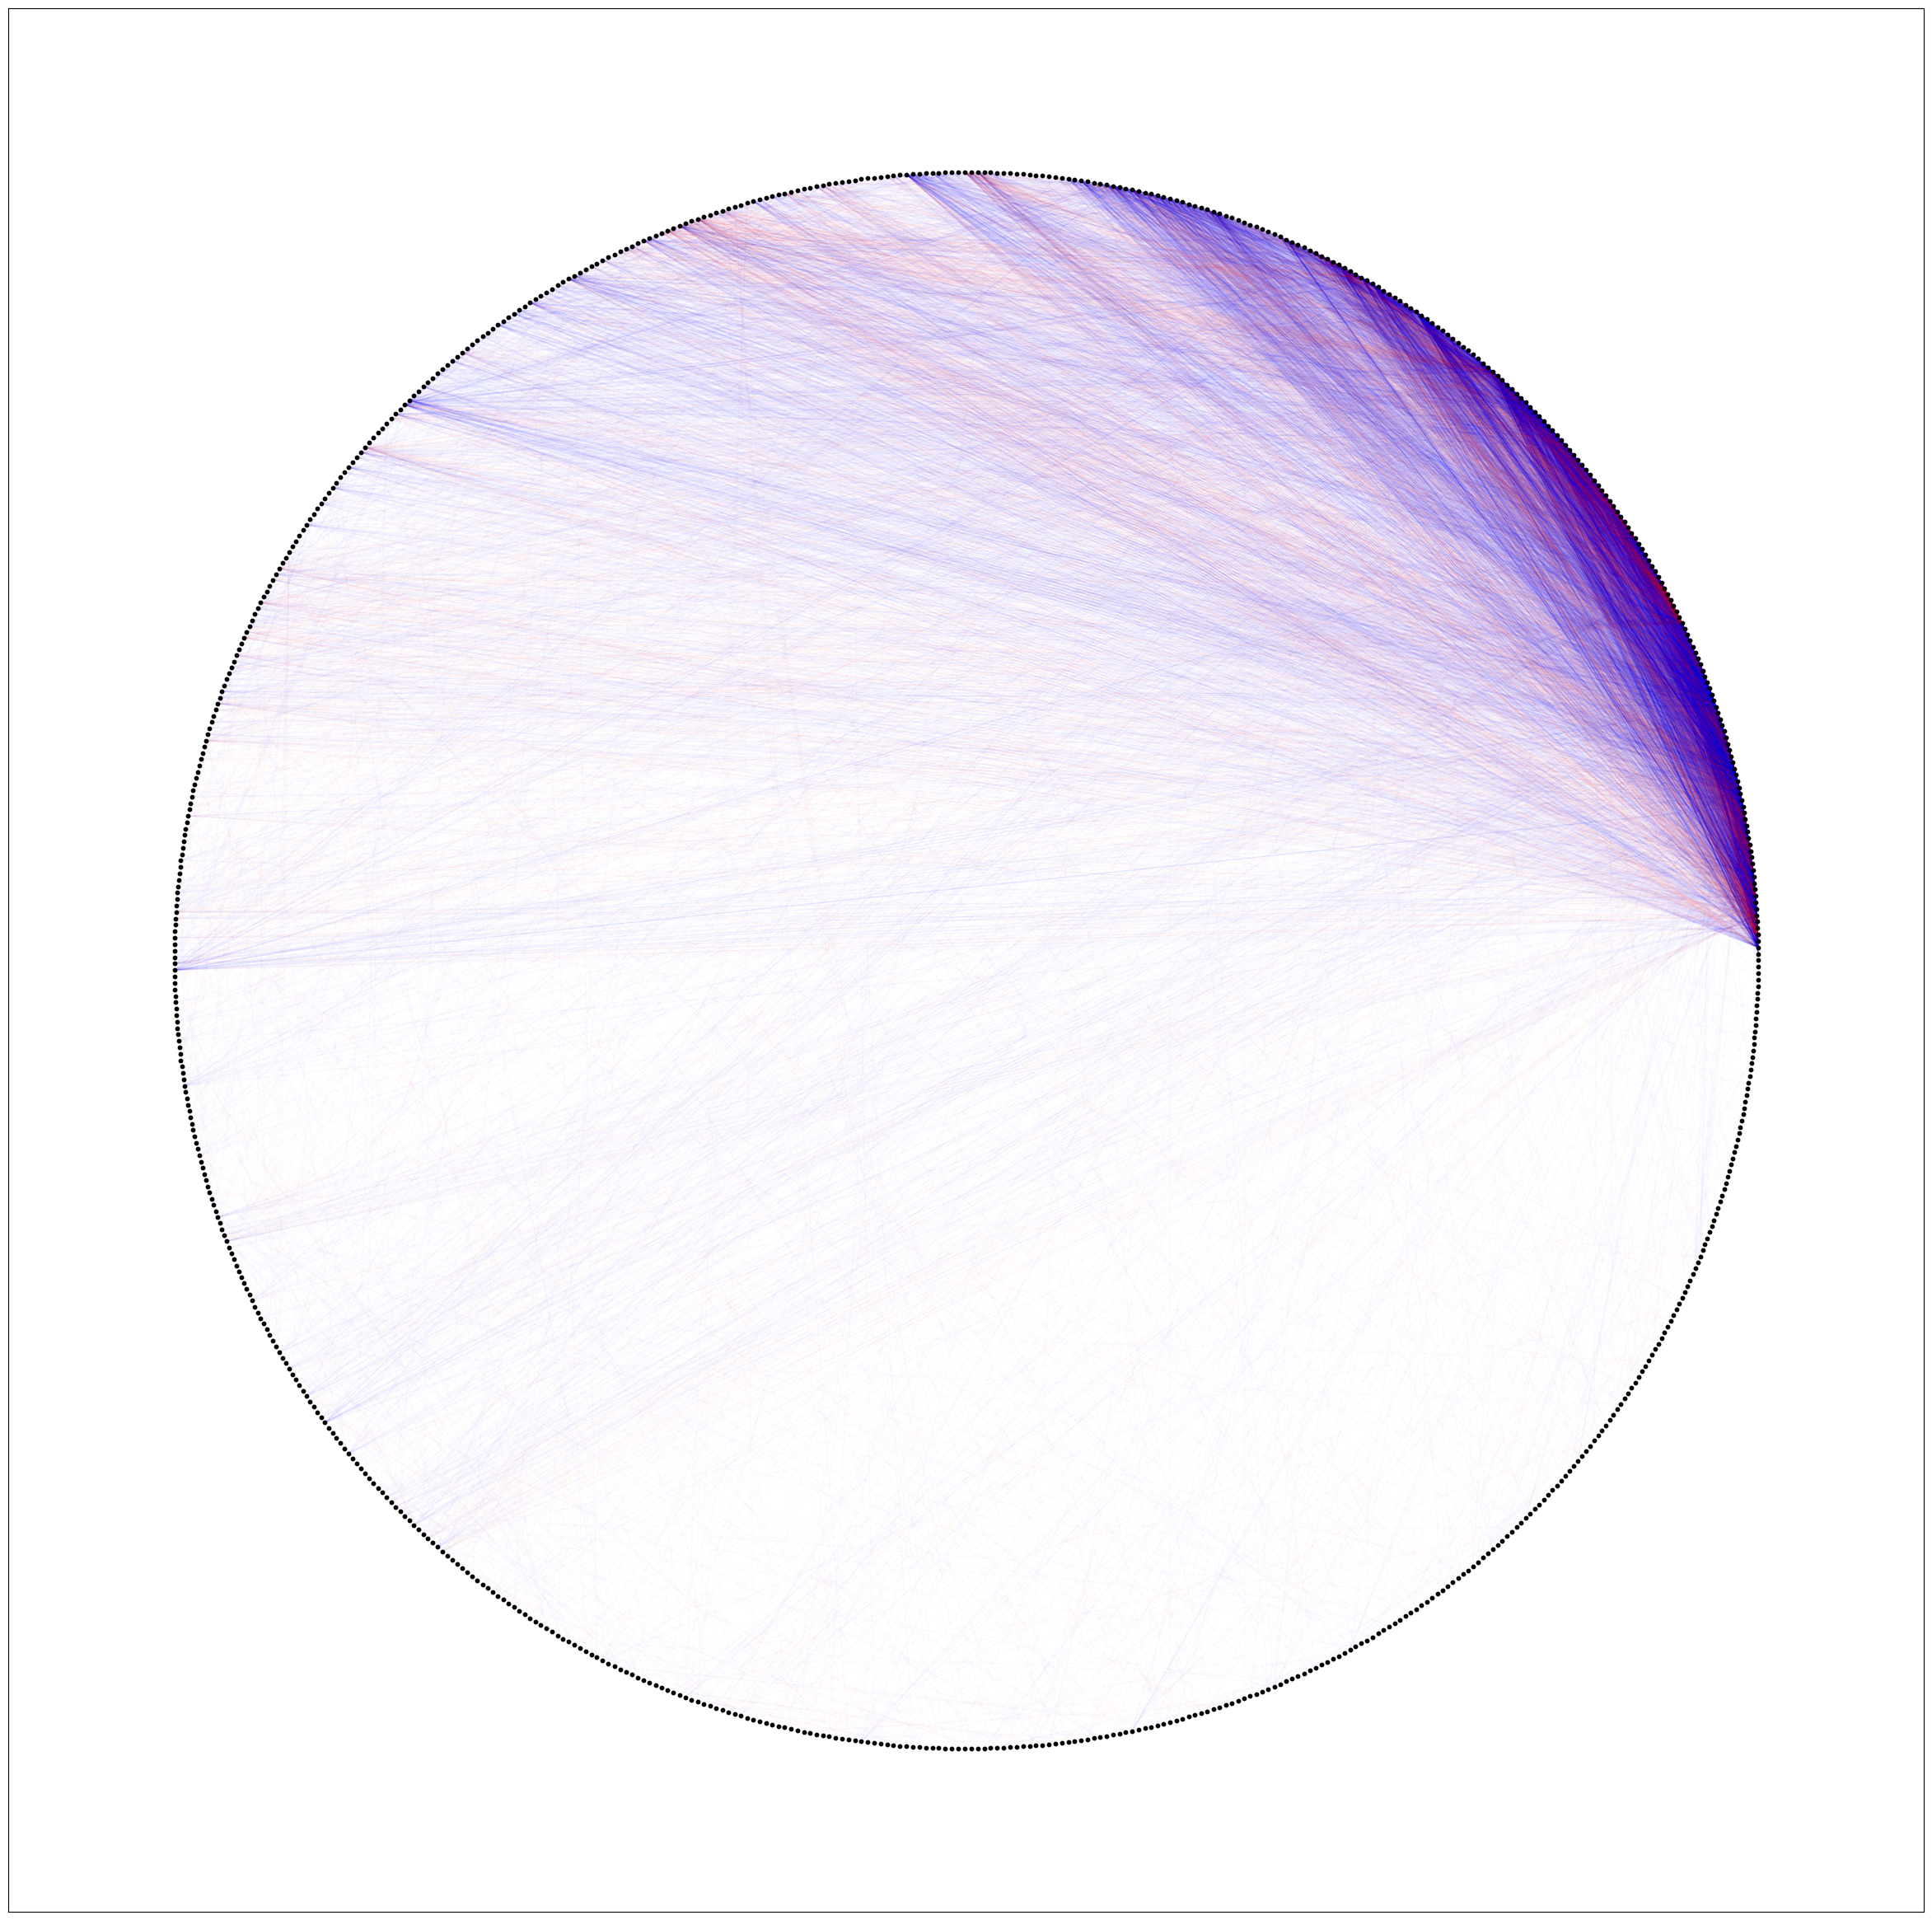

In [14]:
# visualize the edge list graph
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

cleaned = edge_list.copy()
cleaned = cleaned[cleaned['Cooc'] != 0]
cleaned = cleaned[cleaned['TaxonCode_1'] != cleaned['TaxonCode_2']]
cleaned_G = nx.from_pandas_edgelist(cleaned, 'TaxonCode_1', 'TaxonCode_2', ['Cooc'])
G = nx.from_pandas_edgelist(edge_list, 'TaxonCode_1', 'TaxonCode_2', ['Cooc'])
plt.figure(figsize=(30, 30))
options = {
    'node_color':'black',
    'node_size':10
}
node_pos = nx.circular_layout(cleaned_G)
nx.draw_networkx_nodes(cleaned_G,pos=node_pos, **options)
for node1, node2, weight in tqdm(cleaned_G.edges(data='Cooc')):
    if node1 == node2:
        continue
    if weight < 0:
        if weight < -1:
            nx.draw_networkx_edges(cleaned_G, pos=node_pos, edgelist=[(node1, node2)], alpha=1, edge_color='red')
        else:
            nx.draw_networkx_edges(cleaned_G, pos=node_pos, edgelist=[(node1, node2)], alpha=-weight, edge_color='red')
    else:
        if weight > 1:
            nx.draw_networkx_edges(cleaned_G, pos=node_pos, edgelist=[(node1, node2)], alpha=1, edge_color='blue')
        else:
            nx.draw_networkx_edges(cleaned_G, pos=node_pos, edgelist=[(node1, node2)], alpha=weight,  edge_color='blue')
plt.show()

In [32]:
# save the graph
nx.write_gexf(G, 'entire_graph_all_France.gexf')

In [15]:
import pickle as pkl
diatoms_per_sampling_operation = pkl.load(open('diatoms_per_sampling_operation.pkl', 'rb'))

In [16]:
with open('taxon_to_onehot.txt', 'rb') as f:
    taxons = f.readlines()
    taxons = [x.decode('utf-8').strip() for x in taxons]
sampling_ops = list(diatoms_per_sampling_operation.keys())

  0%|          | 0/210 [00:00<?, ?it/s]

100%|██████████| 210/210 [00:00<00:00, 1831.62it/s]


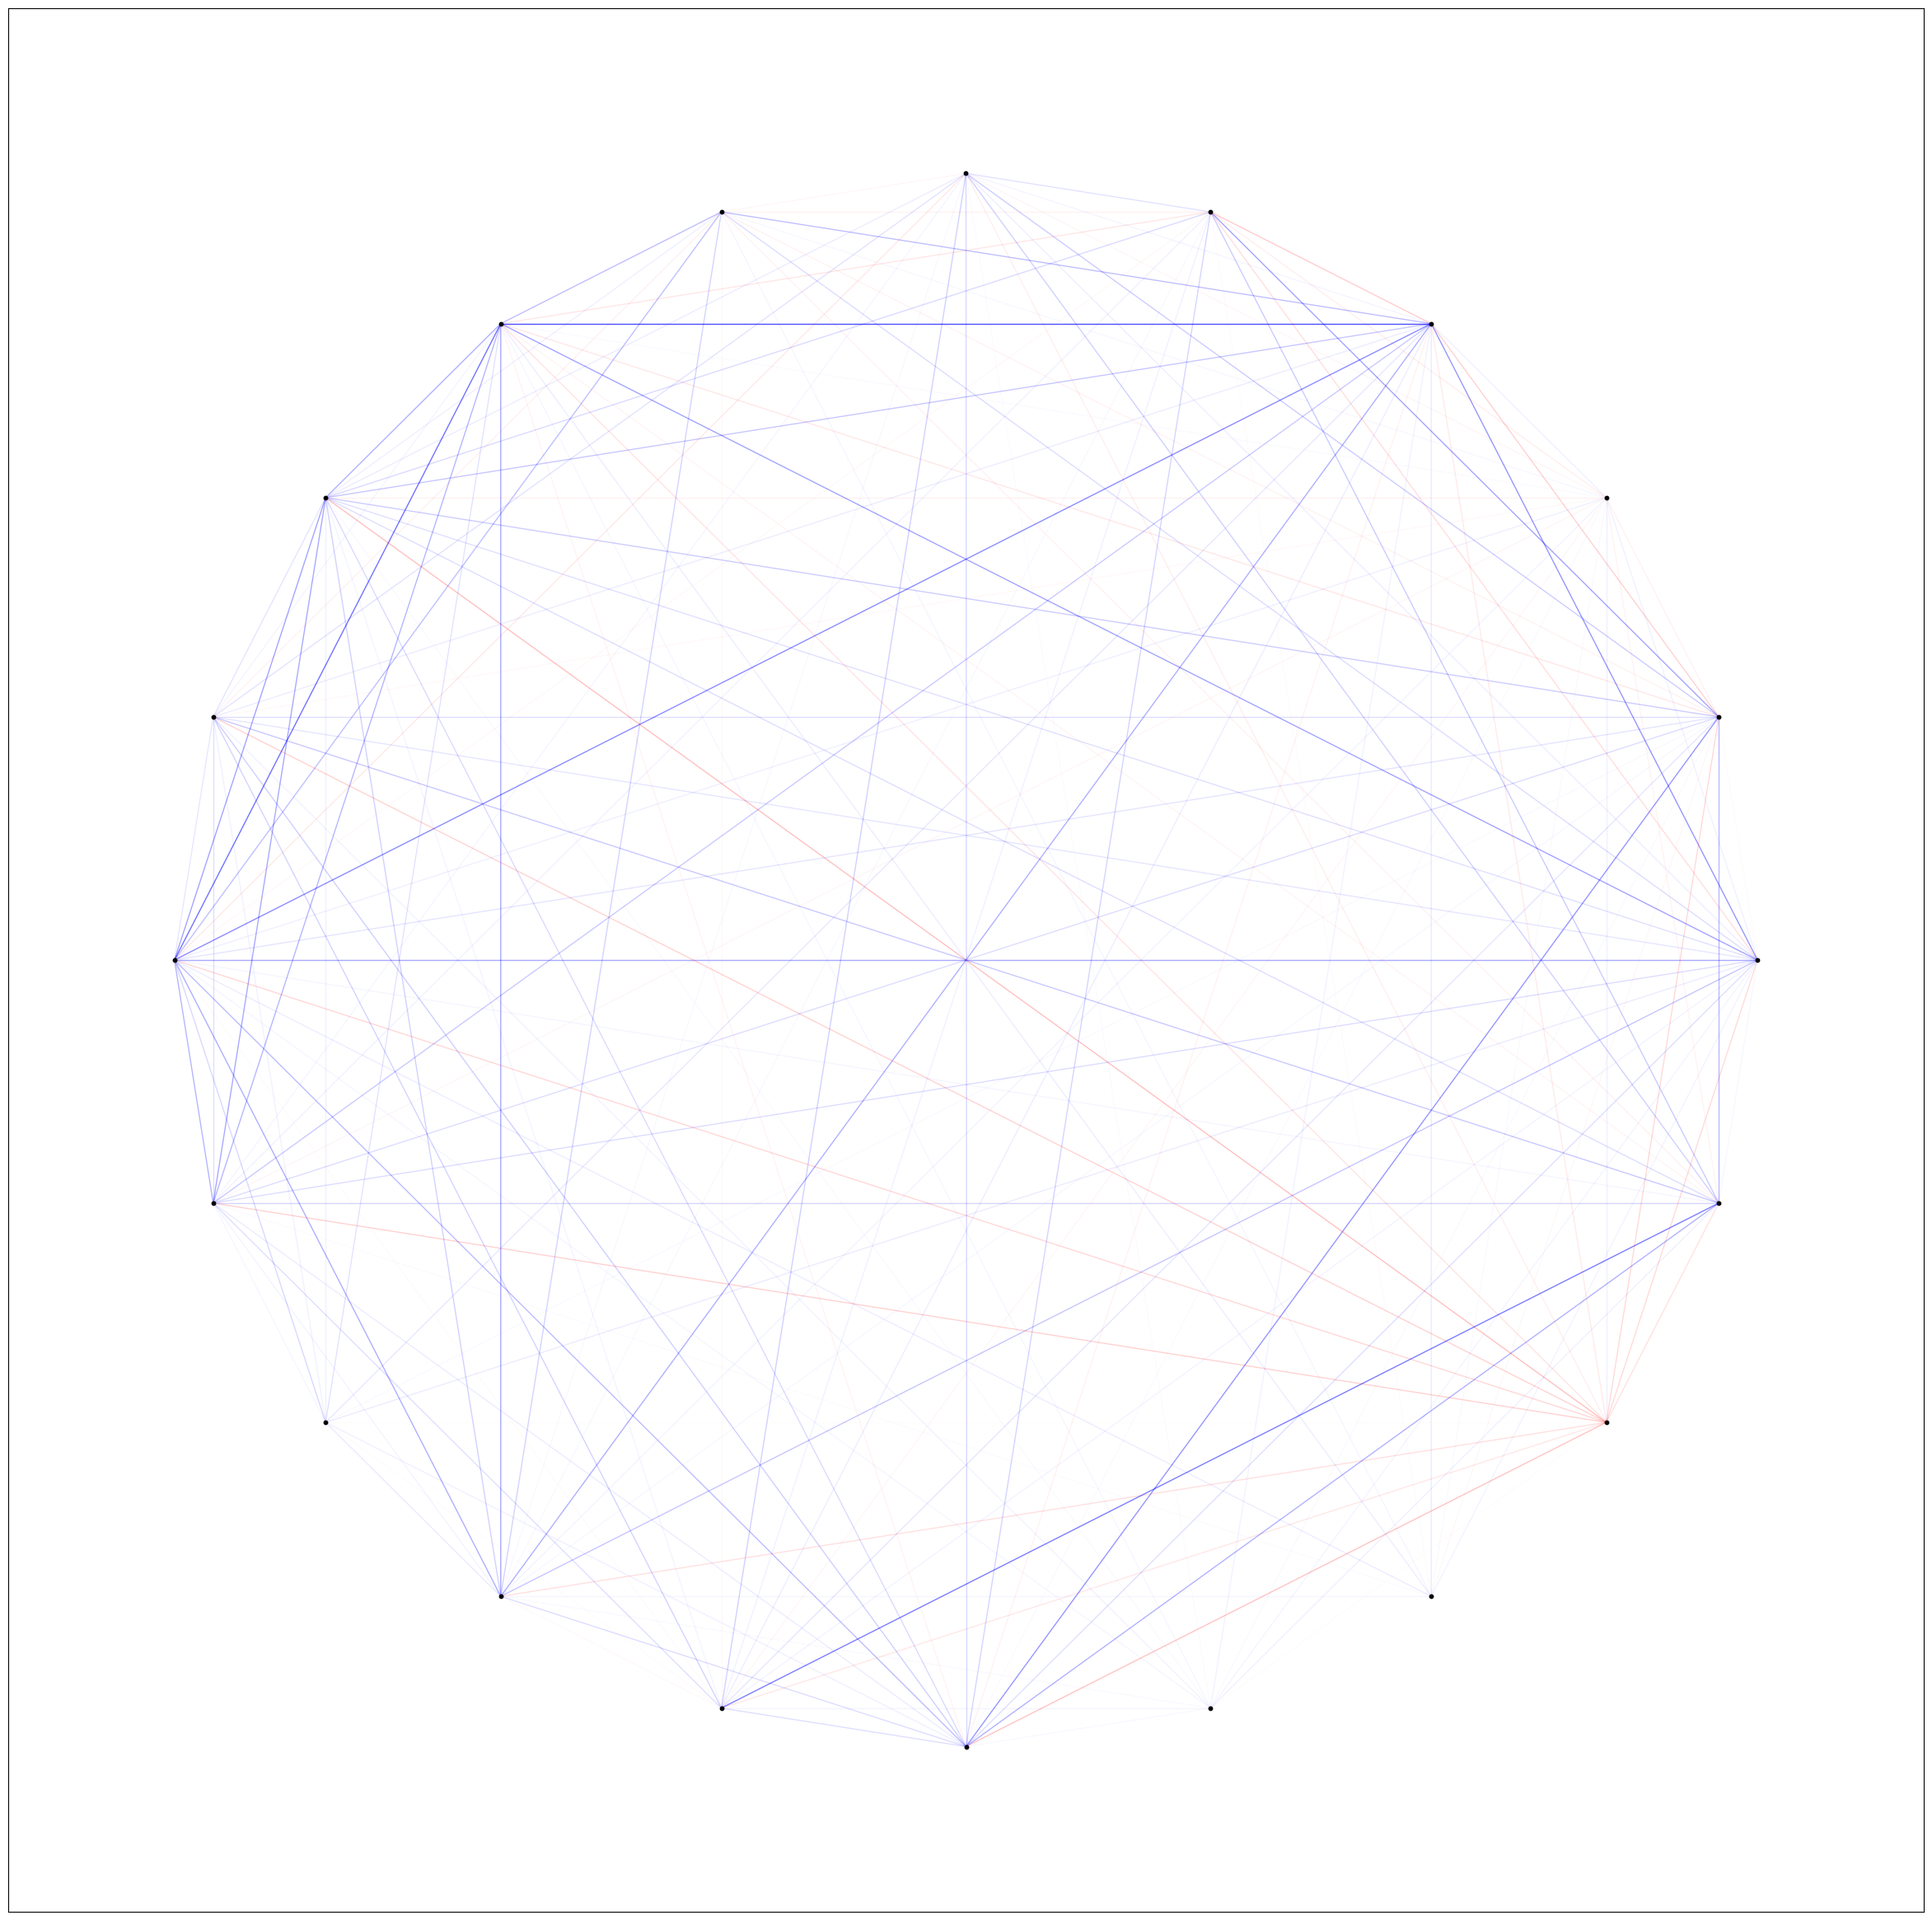

In [35]:
sampling_op = sampling_ops[0]
present_diatoms = diatoms_per_sampling_operation[sampling_op]
present_taxon_codes = [taxons[i] for i in present_diatoms['onehot']]
G_sub = G.subgraph(present_taxon_codes)
plt.figure(figsize=(30, 30))
options = {
    'node_color':'black',
    'node_size':10
}
node_pos = nx.circular_layout(G_sub)
nx.draw_networkx_nodes(G_sub,pos=node_pos, **options)
for node1, node2, weight in tqdm(G_sub.edges(data='Cooc')):
    if node1 == node2:
        continue
    if weight < 0:
        if weight < -1:
            nx.draw_networkx_edges(G_sub, pos=node_pos, edgelist=[(node1, node2)], alpha=1, edge_color='red')
        else:
            nx.draw_networkx_edges(G_sub, pos=node_pos, edgelist=[(node1, node2)], alpha=-weight, edge_color='red')
    else:
        if weight > 1:
            nx.draw_networkx_edges(G_sub, pos=node_pos, edgelist=[(node1, node2)], alpha=1, edge_color='blue')
        else:
            nx.draw_networkx_edges(G_sub, pos=node_pos, edgelist=[(node1, node2)], alpha=weight, edge_color='blue')
plt.show()



In [45]:
def create_graph(sampling_op):
    present_diatoms = diatoms_per_sampling_operation[sampling_op]
    present_taxon_codes = [taxons[i] for i in present_diatoms['onehot']]
    G_sub = G.subgraph(present_taxon_codes)
    node_attrs = {}
    abundancies = {}
    for i, node in enumerate(G_sub.nodes):
        node_attrs[node] = taxons.index(node)
        onehot = taxons.index(node)
        abundancies[taxons.index(node)] = list(present_diatoms[present_diatoms['onehot'] == taxons.index(node)]['Abundance_pm'])[0]
    nx.set_node_attributes(G_sub, node_attrs, 'onehot')
    # remove all edges with weight 0
    G_sub_cleaned = G_sub.copy()
    for node1, node2, weight in G_sub.edges(data='Cooc'):
        if weight == 0:
            G_sub_cleaned.remove_edge(node1, node2)
    data = from_networkx(G_sub_cleaned, group_edge_attrs=['Cooc'], group_node_attrs=['onehot'])
    return data, abundancies
sampling_ops = list(diatoms_per_sampling_operation.keys())
for sampling_op in tqdm(sampling_ops):
    data, abundancies = create_graph(sampling_op)
    data.x = data.x.squeeze()
    if not isinstance(data.x, torch.Tensor):
        data.x = torch.atleast_1d(data.x)
    data.x = data.x.long()
    data.edge_index, data.edge_attr = add_self_loops(data.edge_index, data.edge_attr, fill_value=1.0)
    data.edge_attr = (data.edge_attr + 1) / 2.0 + .00001
    data.abundancies = torch.tensor([abundancies[onehot.item()] for onehot in torch.atleast_1d(data.x)])
    torch.save(data, f'france_wide_graphs/{sampling_op}.pt')
    


  0%|          | 0/49230 [00:00<?, ?it/s]

100%|██████████| 49230/49230 [15:32<00:00, 52.82it/s]  


In [37]:
import os
edge_lists = {}
# for each file in folder EdgeListsHER&ShapeFilesHER_GTstudentproject/EdgeLists_HERlvl1/
# read the file and store it in a dictionary
for file in os.listdir('EdgeListsHER&ShapeFilesHER_GTstudentproject/EdgeLists_HERlvl1/'):
    if file.endswith('.csv'):
        edge_list = pd.read_csv(f'EdgeListsHER&ShapeFilesHER_GTstudentproject/EdgeLists_HERlvl1/{file}', sep=';')
        edge_list['Cooc'] = edge_list['Cooc'].str.replace(',','.')
        edge_list['Cooc'] = edge_list['Cooc'].astype(float)
        code = int(file.split('_')[3].split('=')[1])
        edge_lists[code] = nx.from_pandas_edgelist(edge_list, 'TaxonCode_1', 'TaxonCode_2', ['Cooc'])

print('Graphs processed')

site_infos = pd.read_csv('DataDiatomGNN_GTstudentprojectGT/InfoSamplingsites_GTstudentproject.csv', sep=';')
def create_graph_per_herlvl1(sampling_op):
    site = sampling_op.split('_')[0]
    her_code = int(site_infos[site_infos['CodeSite_SamplingOperations'] == site]['HERlvl1Code'].values[0])
    present_diatoms = diatoms_per_sampling_operation[sampling_op]
    present_taxon_codes = [taxons[i] for i in present_diatoms['onehot']]
    G_sub = edge_lists[her_code].subgraph(present_taxon_codes)
    node_attrs = {}
    abundancies = {}
    for i, node in enumerate(G_sub.nodes):
        node_attrs[node] = taxons.index(node)
        onehot = taxons.index(node)
        abundancies[taxons.index(node)] = list(present_diatoms[present_diatoms['onehot'] == taxons.index(node)]['Abundance_pm'])[0]
    nx.set_node_attributes(G_sub, node_attrs, 'onehot')
    if len(G_sub.nodes) == 0:
        return None, None
    # remove all edges with weight 0
    G_sub_cleaned = G_sub.copy()
    for node1, node2, weight in G_sub.edges(data='Cooc'):
        if weight == 0:
            G_sub_cleaned.remove_edge(node1, node2)
    
    data = from_networkx(G_sub_cleaned, group_edge_attrs=['Cooc'], group_node_attrs=['onehot'])
    return data, abundancies

sampling_ops_to_remove = []
sampling_ops = list(diatoms_per_sampling_operation.keys())
for sampling_op in tqdm(sampling_ops):
    data, abundancies = create_graph_per_herlvl1(sampling_op)
    if data is None:
        sampling_ops_to_remove.append(sampling_op)
        continue
    data.x = data.x.squeeze()
    if not isinstance(data.x, torch.Tensor):
        data.x = torch.atleast_1d(data.x)
    data.x = data.x.long()
    data.edge_index, data.edge_attr = add_self_loops(data.edge_index, data.edge_attr, fill_value=1.0)
    # remove the negative edges
    data.edge_index = data.edge_index[:, (data.edge_attr > 0).squeeze()]
    data.edge_attr = data.edge_attr[data.edge_attr > 0]

    # data.edge_attr = (data.edge_attr + 1) / 2.0 + .00001
    data.abundancies = torch.tensor([abundancies[onehot.item()] for onehot in torch.atleast_1d(data.x)])
    torch.save(data, f'her_lvl_1_zeroed_negatives/{sampling_op}.pt')

for sampling_op in sampling_ops_to_remove:
    sampling_ops.remove(sampling_op)
    diatoms_per_sampling_operation.pop(sampling_op)


Graphs processed


100%|██████████| 49231/49231 [11:02<00:00, 74.29it/s] 


In [17]:
from torch_geometric.data import DataLoader, Dataset
from copy import deepcopy
import torch

valid_ys = ["Nitrogencompounds_Status1Y","Nitrogencompounds_Status180D","Nitrogencompounds_Status90D","Nitrates_Status1Y","Nitrates_Status180D","Nitrates_Status90D","Phosphorouscompounds_Status1Y","Phosphorouscompounds_Status180D","Phosphorouscompounds_Status90D","Acidification_Status1Y","Acidification_Status180D","Acidification_Status90D","PAH_Status1Y","PAH_Status180D","PAH_Status90D","OrganicMatter_Status1Y","OrganicMatter_Status180D","OrganicMatter_Status90D","SuspendedMatter_Status1Y","SuspendedMatter_Status180D","SuspendedMatter_Status90D","OrganicMicropollutants_Status1Y","OrganicMicropollutants_Status180D","OrganicMicropollutants_Status90D","MineralMicropollutants_Status1Y","MineralMicropollutants_Status180D","MineralMicropollutants_Status90D"]
class GraphDataset_SplitSite(Dataset):
    def __init__(self, root, sampling_op_to_tensor, y='Nitrogencompounds_Status1Y', sites=set()):
        super().__init__(root, transform=None, pre_transform=None, pre_filter=None)
        self.sampling_op_to_tensor = deepcopy(sampling_op_to_tensor)
        self.keys = list(self.sampling_op_to_tensor.keys())
        self.y = [valid_ys.index(y)]
        temp = []
        for key in self.keys:
            if self.sampling_op_to_tensor[key][2][self.y].item() == -1:
                continue
            elif key.split('_')[0] not in sites:
                continue
            else:
                temp.append(key)
                self.sampling_op_to_tensor[key][2][self.y] = 1 if self.sampling_op_to_tensor[key][2][self.y].item() >= 2 else 0
        print('Skipped', len(self.keys) - len(temp), 'samples')
        self.keys = temp

        
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        data = torch.load(f'{self.root}/{key}.pt')
        data.x = torch.atleast_1d(data.x)
        # data.x = torch.nn.functional.one_hot(data.x, num_classes=2292).squeeze().float()
        # data.x = torch.atleast_2d(data.x)
        data.y = torch.tensor([self.sampling_op_to_tensor[key][2][self.y]], dtype=torch.float)
        return data, key

In [15]:
# sampling_op_to_tensor = pkl.load(open('sampling_op_to_tensor.pkl', 'rb'))
# sampling_ops_to_remove = ['S05029820_20150602']
# for samp in sampling_ops_to_remove:
#     sampling_op_to_tensor.pop(samp)
# sites = list(set([key.split('_')[0] for key in sampling_op_to_tensor.keys()]))
# train_size = int(0.8 * len(sites))
# val_size = int(0.1 * len(sites))
# test_size = len(sites) - train_size - val_size
# print(train_size, val_size, test_size)
# rand_ind_train = np.random.choice(len(sites), train_size, replace=False)
# train_sites = set([sites[i] for i in rand_ind_train])
# temp = set(sites) - train_sites
# rand_ind_val = np.random.choice(len(temp), val_size, replace=False)
# val_sites = set([sites[i] for i in rand_ind_val])
# test_inds = set([i for i in range(len(temp)) if i not in rand_ind_val])
# test_sites = set([sites[i] for i in test_inds])
# np.save('train_inds.npy', rand_ind_train)
# np.save('val_inds.npy', rand_ind_val)
# np.save('test_inds.npy', list(test_inds))

In [21]:
train_inds = np.load('train_inds.npy')
val_inds = np.load('val_inds.npy')
test_inds = np.load('test_inds.npy')
sampling_op_to_tensor = pkl.load(open('sampling_op_to_tensor.pkl', 'rb'))
sampling_ops_to_remove = ['S05029820_20150602']
for samp in sampling_ops_to_remove:
    sampling_op_to_tensor.pop(samp)
sites = list(set([key.split('_')[0] for key in sampling_op_to_tensor.keys()]))
sites.sort()
np.random.seed(0)
np.random.shuffle(sites)
train_sites = set([sites[i] for i in train_inds])
val_sites = set([sites[i] for i in val_inds])
test_sites = set([sites[i] for i in test_inds])

# train_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=train_sites)
# val_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=val_sites)   
# test_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=test_sites)
train_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='MineralMicropollutants_Status180D', sites=train_sites)
val_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='MineralMicropollutants_Status180D', sites=val_sites)   
test_dataset = GraphDataset_SplitSite('her_lvl_1', sampling_op_to_tensor, y='MineralMicropollutants_Status180D', sites=test_sites)
# train_dataset = GraphDataset_SplitSite('her_lvl_1_negative', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=train_sites)
# val_dataset = GraphDataset_SplitSite('her_lvl_1_negative', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=val_sites)   
# test_dataset = GraphDataset_SplitSite('her_lvl_1_negative', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=test_sites)
# train_dataset = GraphDataset_SplitSite('her_lvl_1_zeroed_negatives', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=train_sites)
# val_dataset = GraphDataset_SplitSite('her_lvl_1_zeroed_negatives', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=val_sites)   
# test_dataset = GraphDataset_SplitSite('her_lvl_1_zeroed_negatives', sampling_op_to_tensor, y='Nitrates_Status1Y', sites=test_sites)

y_dist_bin = {0: 0, 1: 0}
for i in range(len(train_dataset)):
    y_dist_bin[train_dataset[i][0].y.item()] += 1
print('Train Y distribution (0 is Good, 1 is Mediocre/Bad):', y_dist_bin)
y_dist_bin = {0: 0, 1: 0}
for i in range(len(val_dataset)):
    y_dist_bin[val_dataset[i][0].y.item()] += 1
print('Val Y distribution (0 is Good, 1 is Mediocre/Bad):', y_dist_bin)
y_dist_bin = {0: 0, 1: 0}
for i in range(len(test_dataset)):
    y_dist_bin[test_dataset[i][0].y.item()] += 1
print('Test Y distribution (0 is Good, 1 is Mediocre/Bad):', y_dist_bin)

Skipped 33950 samples
Skipped 47298 samples
Skipped 47245 samples


/var/folders/7h/8hn0w0xs40n29dcvw_5nqwch0000gn/T/ipykernel_74515/3746984464.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'{self.root}/{key}.pt')


Train Y distribution (0 is Good, 1 is Mediocre/Bad): {0: 6814, 1: 8466}
Val Y distribution (0 is Good, 1 is Mediocre/Bad): {0: 879, 1: 1053}
Test Y distribution (0 is Good, 1 is Mediocre/Bad): {0: 809, 1: 1176}


In [31]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GraphConv, GATConv
from torch_geometric.nn import global_mean_pool


class GCN(torch.nn.Module):
    def __init__(self, node_features, embedding_size, hidden_channels, num_classes):
        super().__init__()
        self.embedding = torch.nn.Embedding(node_features, embedding_size)
        self.conv1 = GCNConv(embedding_size+1, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # self.conv1 = GraphConv(embedding_size+1, hidden_channels)
        # self.conv2 = GraphConv(hidden_channels, hidden_channels)
        # self.conv1 = GATConv(embedding_size+1, hidden_channels)
        # self.conv2 = GATConv(hidden_channels, hidden_channels)
        self.out1 = torch.nn.Linear(hidden_channels, hidden_channels//4)
        self.out2 = torch.nn.Linear(hidden_channels//4, num_classes)

    def forward(self, data):
        x, edge_index, edge_weights = data.x, data.edge_index, data.edge_attr
        x = self.embedding(x)
        x = torch.cat((x, data.abundancies.unsqueeze(-1)), dim=-1)
        # x = x * data.abundancies.unsqueeze(-1)
        x = self.conv1(x, edge_index, edge_weights)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index, edge_weights)
        x = global_mean_pool(x, data.batch)
        x = F.leaky_relu(self.out1(x))
        x = self.out2(x)
        x = F.log_softmax(x, dim=-1)
        return x


In [33]:
model = GCN(len(taxons), embedding_size=128, hidden_channels=128, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=5, min_lr=0.0001)
def dice_loss(pred, target):
    smooth = 1.
    iflat = pred.contiguous().view(-1)
    tflat = target.contiguous().view(-1)
    intersection = (iflat * tflat).sum()

    A_sum = torch.sum(tflat * iflat)
    B_sum = torch.sum(tflat * tflat)
    
    return 1 - ((2. * intersection + smooth) / (A_sum + B_sum + smooth) )
criterion = dice_loss # torch.nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)
best_val_acc = 0

for epoch in range(25):
    correct = 0
    total = 0
    model.train()
    for i, (batch, keys) in enumerate(train_loader):
        y = batch.y
        y = torch.nn.functional.one_hot(y.long(), num_classes=2)
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, y.long())
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(output.data, 1)
        total += y.size(0)
        # correct += (predicted == y).sum().item()
        correct += (predicted == y.argmax(dim=1)).sum().item()

        if i % 200 == 0:
            print(f'Epoch {epoch}, Loss {loss.item()}, Accuracy {100 * correct / total}, {i}/{len(train_loader)}')
    print(f'Final Epoch Train Accuracy {100 * correct / total}')
    correct = 0
    total = 0
    model.eval()
    for i, (batch, keys) in enumerate(val_loader):
        y = batch.y
        output = model(batch)
        _, predicted = torch.max(output.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    
    print(f'Validation Accuracy {100 * correct / total}')
    scheduler.step(correct / total)
    if 100 * correct / total > best_val_acc:
        best_val_acc = 100 * correct / total
        torch.save(model.state_dict(), 'best_gcn_mineral_model.pt')
        print('Model Saved')

print('Finished Training')
print('Best Validation Accuracy', best_val_acc)

/Users/rithwikseth/miniconda3/envs/water/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/var/folders/7h/8hn0w0xs40n29dcvw_5nqwch0000gn/T/ipykernel_74515/3746984464.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=Tru

Epoch 0, Loss 4.895853042602539, Accuracy 50.0, 0/955
Epoch 0, Loss -1.0219337940216064, Accuracy 53.88681592039801, 200/955
Epoch 0, Loss -1.025791883468628, Accuracy 55.19014962593516, 400/955
Epoch 0, Loss -1.025794267654419, Accuracy 55.490848585690514, 600/955
Epoch 0, Loss -1.0358679294586182, Accuracy 55.438514357053684, 800/955
Final Epoch Train Accuracy 55.274869109947645
Validation Accuracy 54.50310559006211
Model Saved
Epoch 1, Loss -1.0379250049591064, Accuracy 56.25, 0/955
Epoch 1, Loss -1.001929759979248, Accuracy 54.1044776119403, 200/955
Epoch 1, Loss -1.001558542251587, Accuracy 55.11221945137157, 400/955
Epoch 1, Loss -1.0018985271453857, Accuracy 55.126871880199666, 600/955
Epoch 1, Loss -1.0018389225006104, Accuracy 55.32147315855181, 800/955
Final Epoch Train Accuracy 55.38612565445026
Validation Accuracy 54.50310559006211
Epoch 2, Loss -1.0017836093902588, Accuracy 43.75, 0/955
Epoch 2, Loss -1.0032474994659424, Accuracy 55.659203980099505, 200/955
Epoch 2, Loss -

/var/folders/7h/8hn0w0xs40n29dcvw_5nqwch0000gn/T/ipykernel_74515/3592989291.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gcn_mi

Final Test Accuracy 59.24433249370277


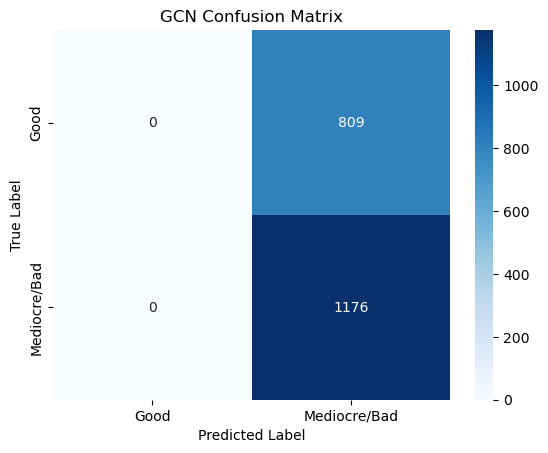

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('best_gcn_mineral_model.pt'))
correct = 0
total = 0
predictions = []
true_classes = []
site_outputs = {}

model.eval()
for i, (batch, keys) in enumerate(tqdm(test_loader)):
    y = batch.y
    output = model(batch)
    _, predicted = torch.max(output.data, 1)
    predictions.extend(predicted)
    true_classes.extend(y)
    total += y.size(0)
    correct += (predicted == y).sum().item()
    # for j, key in enumerate(keys):
    #     k = key.split('_')[0]
    #     if k in site_outputs:
    #         site_outputs[k].append(predicted[j].item() == y[j].item())
    #     else:
    #         site_outputs[k] = [predicted[j].item() == y[j].item()]
print(f'Final Test Accuracy {100 * correct / total}')
conf_matrix = confusion_matrix(true_classes, predictions)

# sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
#           xticklabels=['High', 'Good', 'Mediocre', 'Poor', 'Bad'],
#            yticklabels=['High', 'Good', 'Mediocre', 'Poor', 'Bad'])

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
           xticklabels=['Good', 'Mediocre/Bad'],
            yticklabels=['Good', 'Mediocre/Bad'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GCN Confusion Matrix")
plt.show()

# site_acc = {key: np.mean(val) for key, val in site_outputs.items()}
# sns.boxplot(x=list(site_acc.values()))
# plt.xlabel('Accuracy')
# plt.title('Site Accuracy')
# plt.show()

# sns.histplot(list(site_acc.values()))
# plt.xlabel('Accuracy')
# plt.title('Site Accuracy')
# plt.show()

  0%|          | 0/294 [00:00<?, ?it/s]/var/folders/7h/8hn0w0xs40n29dcvw_5nqwch0000gn/T/ipykernel_38135/1309440206.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data 

Final Test Accuracy 82.33418367346938


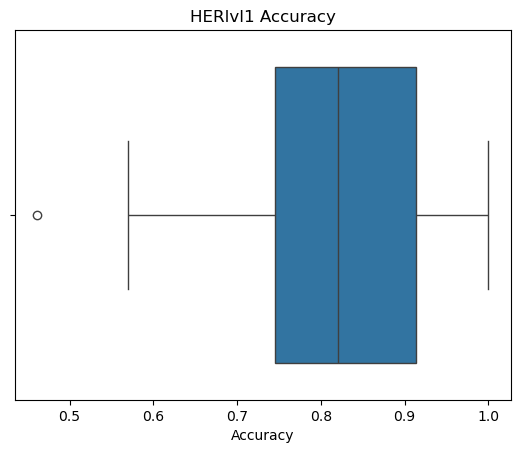

HERlvl1 3, Accuracy 0.8178571428571428, N 560
HERlvl1 11, Accuracy 0.8041958041958042, N 143
HERlvl1 9, Accuracy 0.8915401301518439, N 922
HERlvl1 10, Accuracy 0.7427821522309711, N 381
HERlvl1 13, Accuracy 0.5694444444444444, N 72
HERlvl1 15, Accuracy 0.8235294117647058, N 153
HERlvl1 6, Accuracy 0.6406926406926406, N 231
HERlvl1 4, Accuracy 0.9157894736842105, N 95
HERlvl1 12, Accuracy 0.8813186813186813, N 455
HERlvl1 5, Accuracy 0.7783505154639175, N 194
HERlvl1 18, Accuracy 0.6712328767123288, N 146
HERlvl1 21, Accuracy 0.929368029739777, N 269
HERlvl1 22, Accuracy 0.46153846153846156, N 26
HERlvl1 14, Accuracy 0.7779527559055118, N 635
HERlvl1 7, Accuracy 1.0, N 61
HERlvl1 17, Accuracy 0.7532467532467533, N 77
HERlvl1 1, Accuracy 0.9754098360655737, N 122
HERlvl1 19, Accuracy 0.896551724137931, N 29
HERlvl1 8, Accuracy 0.9069767441860465, N 43
HERlvl1 16, Accuracy 1.0, N 42
HERlvl1 20, Accuracy 0.6, N 15
HERlvl1 2, Accuracy 1.0, N 33


In [69]:
# visualize performance per HERlvl1
correct = 0
total = 0
predictions = []
true_classes = []
herlvl1_outputs = {}

model.eval()
for i, (batch, keys) in enumerate(tqdm(test_loader)):
    y = batch.y
    output = model(batch)
    _, predicted = torch.max(output.data, 1)
    predictions.extend(predicted)
    true_classes.extend(y)
    total += y.size(0)
    correct += (predicted == y).sum().item()
    for j, key in enumerate(keys):
        site = key.split('_')[0]
        her_code = int(site_infos[site_infos['CodeSite_SamplingOperations'] == site]['HERlvl1Code'].values[0])
        if her_code in herlvl1_outputs:
            herlvl1_outputs[her_code].append(predicted[j].item() == y[j].item())
        else:
            herlvl1_outputs[her_code] = [predicted[j].item() == y[j].item()]
print(f'Final Test Accuracy {100 * correct / total}')
herlvl1_acc = {key: np.mean(val) for key, val in herlvl1_outputs.items()}
sns.boxplot(x=list(herlvl1_acc.values()))
plt.xlabel('Accuracy')
plt.title('HERlvl1 Accuracy')
plt.show()

for key, val in herlvl1_acc.items():
    print(f'HERlvl1 {key}, Accuracy {val}, N {len(herlvl1_outputs[key])}')

        

In [72]:
correct = 0
total = 0
predictions = []
true_classes = []
herlvl1_counts = {}

model.eval()
for i, (batch, keys) in enumerate(tqdm(train_loader)):
    for j, key in enumerate(keys):
        site = key.split('_')[0]
        her_code = int(site_infos[site_infos['CodeSite_SamplingOperations'] == site]['HERlvl1Code'].values[0])
        if her_code in herlvl1_counts:
            herlvl1_counts[her_code][0] += 1
        else:
            herlvl1_counts[her_code] = [0, 0, 0]
for i, (batch, keys) in enumerate(tqdm(val_loader)):
    for j, key in enumerate(keys):
        site = key.split('_')[0]
        her_code = int(site_infos[site_infos['CodeSite_SamplingOperations'] == site]['HERlvl1Code'].values[0])
        if her_code in herlvl1_counts:
            herlvl1_counts[her_code][1] += 1
        else:
            herlvl1_counts[her_code] = [0, 0, 0]
for i, (batch, keys) in enumerate(tqdm(test_loader)):
    for j, key in enumerate(keys):
        site = key.split('_')[0]
        her_code = int(site_infos[site_infos['CodeSite_SamplingOperations'] == site]['HERlvl1Code'].values[0])
        if her_code in herlvl1_counts:
            herlvl1_counts[her_code][2] += 1
        else:
            herlvl1_counts[her_code] = [0, 0, 0]

for key, val in herlvl1_counts.items():
    print(f'HERlvl1 {key}, Train {val[0]}, Val {val[1]}, Test {val[2]}')


  0%|          | 0/2417 [00:00<?, ?it/s]/var/folders/7h/8hn0w0xs40n29dcvw_5nqwch0000gn/T/ipykernel_38135/1309440206.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data

HERlvl1 9, Train 7980, Val 1015, Test 922
HERlvl1 17, Train 656, Val 66, Test 77
HERlvl1 12, Train 3623, Val 458, Test 455
HERlvl1 5, Train 1876, Val 210, Test 194
HERlvl1 14, Train 6315, Val 954, Test 635
HERlvl1 3, Train 3797, Val 454, Test 560
HERlvl1 11, Train 962, Val 117, Test 143
HERlvl1 15, Train 914, Val 138, Test 153
HERlvl1 20, Train 425, Val 57, Test 15
HERlvl1 6, Train 1596, Val 287, Test 231
HERlvl1 18, Train 949, Val 139, Test 146
HERlvl1 1, Train 1140, Val 108, Test 122
HERlvl1 16, Train 283, Val 16, Test 42
HERlvl1 21, Train 2130, Val 211, Test 269
HERlvl1 10, Train 3107, Val 431, Test 381
HERlvl1 8, Train 401, Val 48, Test 43
HERlvl1 13, Train 826, Val 89, Test 72
HERlvl1 4, Train 488, Val 41, Test 95
HERlvl1 19, Train 395, Val 87, Test 29
HERlvl1 2, Train 271, Val 35, Test 33
HERlvl1 7, Train 426, Val 33, Test 61
HERlvl1 22, Train 87, Val 3, Test 26
